DBSCAN in Python

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN, KMeans
from sklearn.datasets import make_moons

In [2]:
X,y=make_moons(n_samples=400,noise=0.07,random_state=42)
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (400, 2)
y shape: (400,)


Rappresentazione grafica del dataset

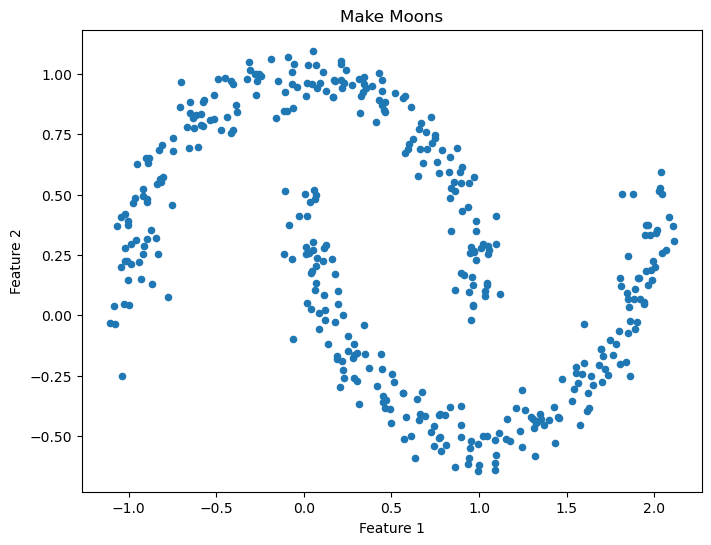

In [6]:
plt.figure(figsize=(8,6))
plt.scatter(X[:,0],X[:,1],s=20)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Make Moons")
plt.show()

Sono due mezze lune, non sono lineari
Dati che non rispettano relazioni lineari tra loro, pertanto ottimo DBScan

Applichiamo DBScan, non richieede senza standarizzazione ne normalizzazione dei dati, poichè è in grado di trovare automaticamente i cluster.
Ha bisogno di due parametri eps e min_samples.

In [ ]:
eps=0.2
min_samples=5
dbscan=DBSCAN(eps=eps, min_samples=min_samples)
dbscan.fit(X)
labels=dbscan.labels_
#print(labels)

[ 0  0  1  0  1  1  0  1  0  1  1  0  1  1  1  1  0  0  0  0  1  1  0  0
  1  0  1  0  0  1  0  1  0  1  0  1  1  0  1  1  0  1  1  1  1  0  1  1
  1  1  1  0  0  1  0  1  0  1  1  1  1  0  0  1  1  1  0  0  0  1  0  1
  1  1  0  0  0  0  1  0  1  1  0  0  0  1  0  0  1  1  0  0  1  0  1  0
  0  0  0  1  0  1  1  1  1  1  1  1  0  0  1  0  0  0  0  1  1  0  0  0
  1  1  1  0  1  1  0  0  1  0  0  1  0  1  1  1  0  0  0  0  1  1  0  1
  1  0  1  1  1  0  1  0  0  1  1  1  1  1  0  0  0  0  0  1  0  1  0  1
  1  0  1  1  1  1  1  0  1  0  1  1  1  1  1  1  1  1  0  0  0  1  1  1
  0  1  0  0  0  0  0  0  1  0  0  0  0  1  1  1  0  1  0  1  1  0  0  1
  0  0  0  0  0  1  0  1  1 -1  1  0  1  0  1  0  0  1  1  0  0  0  0  0
  0  1  1  0  1  1  0  1  0  0  1  0  1  0  1  0  1  1  0  1  1  1  1  1
  1  1  0  0  0  1  1  0  0  0  1  1  0  0  0  0  1  0  0  1  0  0  0  1
  1  0  1  1  1  0  0  0  1  0  0  0  0  1  0  1  1  1  1  1  1  0  1  1
  1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0

Statistiche

In [16]:
n_clusters=len(set(labels))-(1 if -1 in labels else 0)
assegnati=np.sum(labels != -1)
totali=len(labels)
errori=totali-assegnati
print(f"N. di cluster trovati: {n_clusters} \nN. di noise trovati: {errori} \nEtichettati: {assegnati} \nPercentuale assegnati: {assegnati/totali*100:.2f} ")

N. di cluster trovati: 2 
N. di noise trovati: 1 
Etichettati: 399 
Percentuale assegnati: 99.75 


Rappresentazione grafica

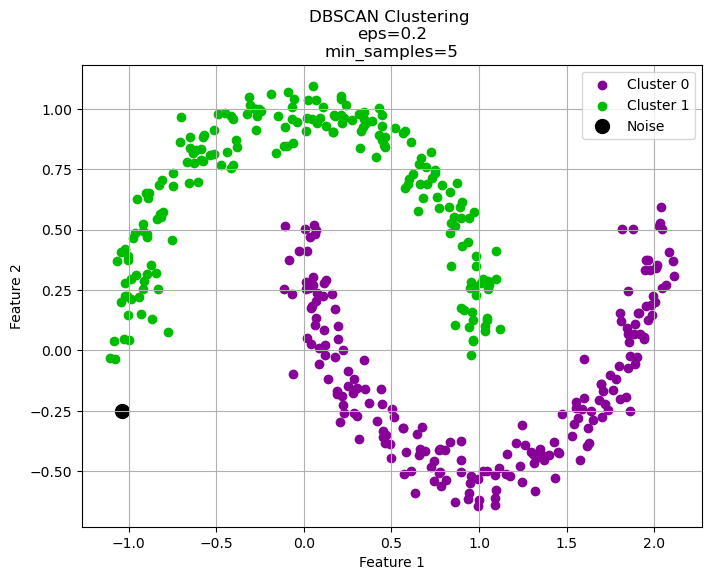

In [ ]:
plt.figure(figsize=(8,6))
unique_labels=set(labels)
colors=[plt.cm.nipy_spectral(each) for each in np.linspace(0.1,0.9,len(unique_labels))]
# faccio np.linspace(0.1,0.9,len(unique_labels)) invece di np.linspace(0,1,len(unique_labels))
#per eliminare le estremetà che sono colori nero o molto scuri.
#il nero è assegnato ai noise
# nipy_spectral genera una palette di colori da numeri da 0 a 1, colori continui su tutti lo spettro

for k, col in zip(unique_labels,colors): # unisce labels con colori
    if k==-1: #se noise  
        #col=(0,0,0,1) #colore = nero
        continue #esco dal for per fare lo scatter dei noise separatamente
    class_member_mask=(labels==k) #creo la maschera della label=k
    xy=X[class_member_mask] #filtro i dati della label=k utilizzando la maschera appena creata
    plt.scatter(xy[:,0],xy[:,1],c=[col],label=f"Cluster {k}" if k!=-1 else "Noise") #disegno lo scatter
#scatter dei noise (s=100 pallino più grande rispetto agli altri)
xy_noise=X[(labels==-1)]
plt.scatter(xy_noise[:,0],xy_noise[:,1],c='black', label='Noise',s=100)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title(f"DBSCAN Clustering \neps={eps}\nmin_samples={min_samples}")
plt.legend()
plt.grid()
plt.show()

K-Means qui fa cluster male perchè non ha una forma semplice.


In [37]:
kmeans=KMeans(n_clusters=n_clusters,init='k-means++',random_state=42)
clusters=kmeans.fit_predict(X)

c:\Users\uberti\.conda\envs\ai_epicode\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


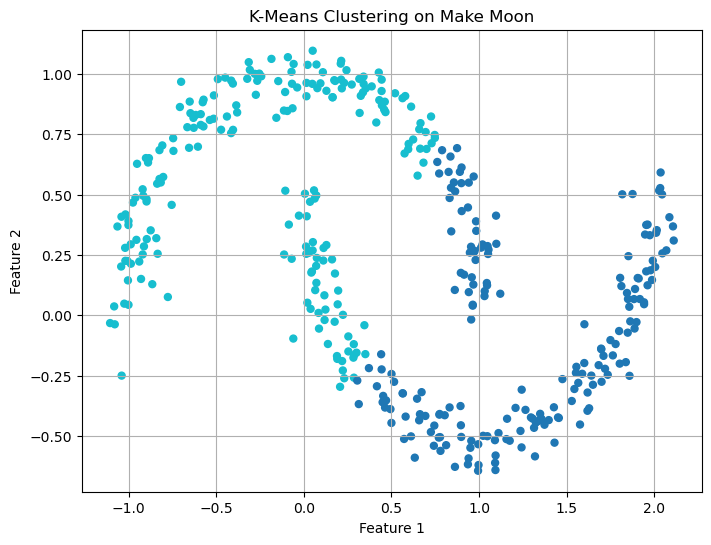

In [38]:
plt.figure(figsize=(8,6))
plt.title("K-Means Clustering on Make Moon")
plt.scatter(X[:,0],X[:,1],c=clusters,cmap="tab10",s=25)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid()
plt.show()

k-means con stesso numero di cluster non rileva i cluster bene come il dbscan
il primo cluster (quello a sinistra), comprende sia quello che dbscan ha etichettato come rumore, sia parte del secondo cluster (di dbscan)
In generale entrambi i cluster seguono una forma circa sferica, ed è proprio qui che kmeans è generalmente buono, main questa situazione fa meglio dbscan